**PERÍODO ACADÉMICO:** 2026-A  
**ASIGNATURA:** ICCD523 Inteligencia Artificial
**GRUPO:** GR1CC  
**FECHA DE ENTREGA LÍMITE:** 06/05/2026   
**ALUMNO:** Renato Aguilar

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ==========================================
# Problema de las 8 reinas con Hill Climbing
# ==========================================

## Funciones auxiliares

In [10]:
n = 8  # número de reinas y tamaño del tablero
#Calcula las heurísticas según los pares de reinas que se atacan
def h(solucion):
    ataques = 0

    for col1 in range(n - 1):
        for col2 in range(col1 + 1, n):

            misma_fila = solucion[col1] == solucion[col2]

            misma_diagonal = abs(solucion[col1] - solucion[col2]) == abs(col1 - col2)

            if misma_fila or misma_diagonal:
                ataques += 1

    return ataques

In [11]:
#Obtiene los vecinos para aplicar los algoritmos
def get_neighbors(solucion):
    vecinos = []

    for columna in range(n):
        for fila in range(n):

            if fila != solucion[columna]:
                vecino = solucion.copy()
                vecino[columna] = fila
                vecinos.append(vecino)
    return vecinos

In [14]:
def draw_board(solucion, titulo):
    fig, ax = plt.subplots(figsize=(7, 7))

    for fila in range(n):
        for col in range(n):
            color = "#F0D9B5" if (fila + col) % 2 == 0 else "#B58863"
            square = patches.Rectangle((col, fila), 1, 1, facecolor=color)
            ax.add_patch(square)

    for col, fila in enumerate(solucion):
        ax.text(
            col + 0.5, fila + 0.5, "♛",
            ha="center", va="center",
            fontsize=28, color="black"
        )

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_xticks([i + 0.5 for i in range(n)])
    ax.set_yticks([i + 0.5 for i in range(n)])
    ax.set_xticklabels(range(n))
    ax.set_yticklabels(range(n))
    ax.invert_yaxis()   
    ax.set_aspect("equal")

    plt.title(f"{titulo} | h = {h(solucion)}", fontsize=14)
    plt.grid(False)
    plt.show()

## Hill Climbing simple

In [12]:
def hill_climbing(start, max_iter=1000):
    current = start.copy()
    historial = [h(current)]

    for _ in range(max_iter):

        vecinos = get_neighbors(current)

        costos = np.array([h(vecino) for vecino in vecinos])

        mejor_costo = costos.min()
        costo_actual = h(current)

        # Si ningún vecino mejora la solución actual,
        # se llegó a un máximo/mínimo local
        if mejor_costo >= costo_actual:
            return current, historial

        # Si hay varios vecinos igual de buenos,
        # escogemos uno aleatoriamente
        mejores_indices = np.where(costos == mejor_costo)[0]
        elegido = np.random.choice(mejores_indices)

        current = vecinos[elegido]
        historial.append(h(current))

        if h(current) == 0:
            return current, historial

    return current, historial

## Hill Climbing con reinicios aleatorios

In [13]:
def random_restart_hill_climbing(n_restarts):
    best_solution = None
    best_cost = np.inf
    best_start = None
    costos_finales = []
    intento_solucion = None

    for intento in range(1, n_restarts + 1):

        start = np.random.randint(n, size=n)

        solution, historial = hill_climbing(start)

        cost = h(solution)

        costos_finales.append(cost)

        if cost < best_cost:
            best_solution = solution
            best_cost = cost
            best_start = start

        if cost == 0:
            intento_solucion = intento
            break

    return best_start, best_solution, best_cost, costos_finales, intento_solucion

### Solución inicial aleatoria

Solución inicial aleatoria:
[0 7 5 0 6 3 2 3]
h(inicial): 7


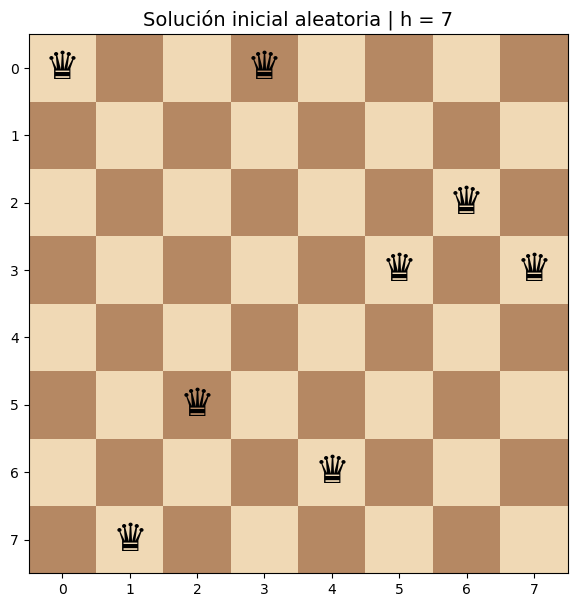

In [17]:
np.random.seed(2)

# Solución inicial aleatoria
start = np.random.randint(n, size=n)

print("Solución inicial aleatoria:")
print(start)
print("h(inicial):", h(start))

draw_board(start, "Solución inicial aleatoria")

### Solución Hill Climbing simple


Solución con Hill-Climbing simple:
[1 3 5 0 6 4 2 7]
h(simple): 1
Historial de h: [7, 4, 3, 2, 1]


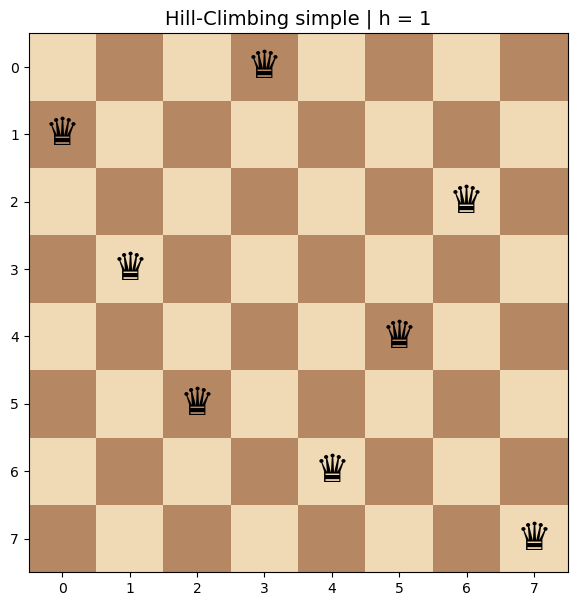

In [18]:
solution_simple, historial_simple = hill_climbing(start)

print("\nSolución con Hill-Climbing simple:")
print(solution_simple)
print("h(simple):", h(solution_simple))
print("Historial de h:", historial_simple)

draw_board(solution_simple, "Hill-Climbing simple")

### Solución Hill Climbing con reinicios aleatorios


Mejor solución con reinicios aleatorios:
[4 6 0 3 1 7 5 2]
h(reinicios): 0

Solución inicial que produjo la mejor solución:
[6 6 7 3 1 7 2 0]

Intento en el que se encontró h = 0:
4

Costos finales por reinicio:
[1, 1, 1, 0]


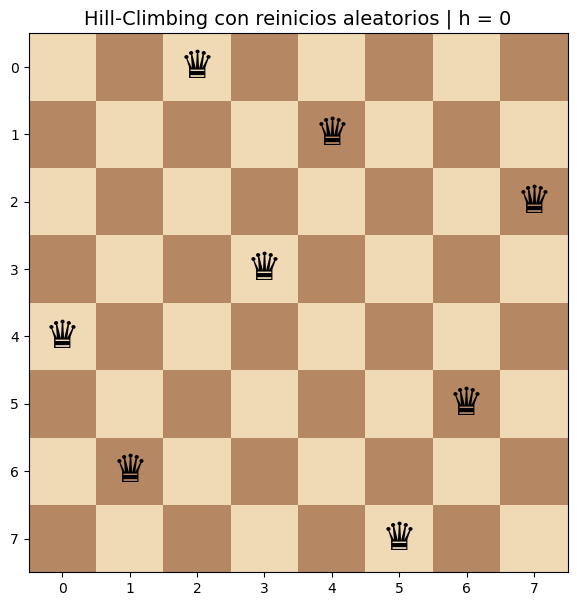

In [19]:
best_start, best_solution, best_cost, costos, intento = random_restart_hill_climbing(1000)

print("\nMejor solución con reinicios aleatorios:")
print(best_solution)
print("h(reinicios):", best_cost)

print("\nSolución inicial que produjo la mejor solución:")
print(best_start)

print("\nIntento en el que se encontró h = 0:")
print(intento)

print("\nCostos finales por reinicio:")
print(costos)

draw_board(best_solution, "Hill-Climbing con reinicios aleatorios")